# pm4py-ucm — model families and performance overlays

Many event logs mix cases that follow **different processes**: a
cancer-care log contains distinct pathways per cancer type; the claims
log used here routes work differently per product group and country.
Mining one model over such a log yields an unreadable union; mining
fully separate models loses what the pathways share.

This notebook walks through the **model-family** pipeline
(`partition → family → assembly`), the **performance overlays**,
and the **family statistics reports** added in v0.4.0–v0.5.0:

1. detect the case-level attributes usable as partition axes;
2. preview the partition (a coverage table — *before* mining anything);
3. mine one UCM per attribute combination and render them side by side;
4. export the family: one `.jucm` per cell, or one **combined** file
   with shared definitions;
5. assemble the **umbrella** — one overarching model whose root map is
   the *shared skeleton* of the family, with **dynamic stubs** at the
   points of divergence: *stubs are variation points, plug-in maps are
   variants, scenario strategies are configurations*;
6. overlay **frequencies and times** on activities and edges, in the
   PNG and as jUCMNav metadata;
7. compute **comparative statistics** for the whole family (process /
   activity / edge / choice level) and write the **self-contained
   interactive HTML report**.

Reference documentation: [`docs/model_families.md`](../docs/model_families.md).
Everything shown here is also available point-and-click in the V3 web
app (`web/streamlit_app_v3.py`, **Family** and **Compare** tabs).

## 1. Setup

Requires `pm4py-ucm` (this repo) and `pm4py`. The graphviz binary must
be on `PATH` for the renderings. The example log is the bundled
`ClaimsPaymentLog` (5 600 cases, 78 126 events) — synthetic but
realistic insurance-claims handling with per-case attributes
(`Product_Group`, `Country`, `Broker`, `Claim_Value`, …) and both a
completion and a start timestamp per event (an *interval* log, so
activity service times are derivable).

In [1]:
import sys
import zipfile
from pathlib import Path

# Import the repo's pm4py_ucm even without `pip install -e .`.
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "pm4py_ucm").is_dir():
    if (REPO_ROOT.parent / "pm4py_ucm").is_dir():
        REPO_ROOT = REPO_ROOT.parent  # running from demo/
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import pm4py
import pm4py_ucm

DEMO = REPO_ROOT / "demo"
OUT = DEMO / "output" / "families"
OUT.mkdir(parents=True, exist_ok=True)

log_path = DEMO / "ClaimsPaymentLog.xes"
if not log_path.exists():
    with zipfile.ZipFile(DEMO / "ClaimsPaymentLog.zip") as zf:
        zf.extractall(DEMO)

log = pm4py.read_xes(str(log_path))
df = log if isinstance(log, pd.DataFrame) else pm4py.convert_to_dataframe(log)
print(f"{df['case:concept:name'].nunique():,} cases, "
      f"{len(df):,} events, "
      f"{df['concept:name'].nunique()} activities")

C:\Users\jucmn\AppData\Roaming\Python\Python313\site-packages\pm4py\utils.py:1005: UserWarning: In the current version, the import/export operation uses `r4pm` by default for importing/exporting files faster.
  warnings.warn(


5,600 cases, 78,126 events, 25 activities


In [2]:
# Small helper: display a (possibly huge) PNG inline as a bounded
# preview, keeping the full-resolution file on disk.
from IPython.display import Image, display
from PIL import Image as PILImage

PILImage.MAX_IMAGE_PIXELS = 1_000_000_000

def show(png_path, max_width=1400, crop=None):
    with PILImage.open(png_path) as im:
        if crop:
            im = im.crop(crop)
        if im.width > max_width:
            ratio = max_width / im.width
            im = im.resize((max_width, int(im.height * ratio)),
                           PILImage.LANCZOS)
        preview = Path(png_path).with_suffix(".preview.png")
        im.convert("RGB").save(preview)
    display(Image(filename=str(preview)))

## 2. Which attributes can partition this log?

`detect_case_attributes` finds the **case-constant** attributes —
including event-level columns that real-world XES exports repeat on
every event — and classifies each into a jUCMNav-compatible type
(the same machinery the data-driven scenario synthesis uses).

In [3]:
from pm4py_ucm.algo.discovery.families import detect_case_attributes

specs, per_case = detect_case_attributes(df)
pd.DataFrame([
    {"attribute": s.source_name, "type": s.type,
     "distinct values": per_case[s.source_name].nunique(),
     "missing %": round(per_case[s.source_name].isna().mean() * 100, 1)}
    for s in specs.values()
]).sort_values("attribute").reset_index(drop=True)

,attribute,type,distinct values,missing %
0,Broker,enumeration,12,0.0
1,Channel,enumeration,3,0.0
2,Claim_Value,integer,5592,0.0
3,Country,enumeration,5,0.0
4,Product_Group,enumeration,7,0.0


## 3. Preview the partition before mining anything

`partition_log` slices the log without mining, so you can check the
cell sizes first — models mined from a handful of cases overfit badly.
Numeric attributes (here `Claim_Value`) are **binned** into quantile
ranges; low-frequency enumeration values merge into an *Other* bucket
past a cardinality cap; missing values get an *Unknown* bucket; and
`min_cases` skips combinations too small to mine (they stay visible,
grayed, in the grid rendering).

In [4]:
from pm4py_ucm.algo.discovery.families import partition_log

part = partition_log(df, ["Product_Group", "Claim_Value"],
                     bins=3, min_cases=50)
counts = part.grid_counts()
rows = [v.label for v in part.attributes[0].values]
cols = [v.label for v in part.attributes[1].values]
pd.DataFrame({c: [counts.get((r, c), 0) for r in rows] for c in cols},
             index=pd.Index(rows, name="Product_Group"))

,1.71-5261.1,5261.1-14173.2,14173.2-95684.1
Product_Group,,,
Boat,64,66,51
Content,234,246,266
Health,646,613,635
Motor,407,392,398
Pet,30,27,32
Property,339,352,313
Travel,147,170,172


## 4. Mine a family and render it side by side

`discover_ucm_family` runs the same pipeline as
`discover_ucm_inductive` per cell — the `decomposition` argument
applies per cell, so families can be flat or hierarchical. Each
`FamilyCell` carries its own standalone `UCM`, its case ids, and its
own mined `{activity: performer}` mapping (which will matter for the
umbrella below).

In [5]:
family = pm4py_ucm.discover_ucm_family(
    df, ["Product_Group"],
    min_cases=50, noise_threshold=0.2,
)
pd.DataFrame([
    {"cell": c.label, "cases": c.n_cases,
     "coverage": f"{c.coverage * 100:.1f}%",
     "activities": len(c.ucm.responsibilities)}
    for c in family.cells
])

,cell,cases,coverage,activities
0,Boat,181,3.2%,25
1,Content,746,13.3%,25
2,Health,1894,33.8%,25
3,Motor,1197,21.4%,25
4,Pet,89,1.6%,25
5,Property,1004,17.9%,25
6,Travel,489,8.7%,25


`save_vis_ucm_family` renders the whole family into one PNG — a
vertical **stack** for one attribute, a rows × columns **matrix** for
two — with each panel captioned `n=… (…%)`. Resolution adapts: it aims
for 192 dpi so exported text stays readable, backing off toward the
96-dpi floor only when the composite would exceed a pixel budget.
(The inline image below is a bounded preview; the full-resolution file
is in `output/families/`.)

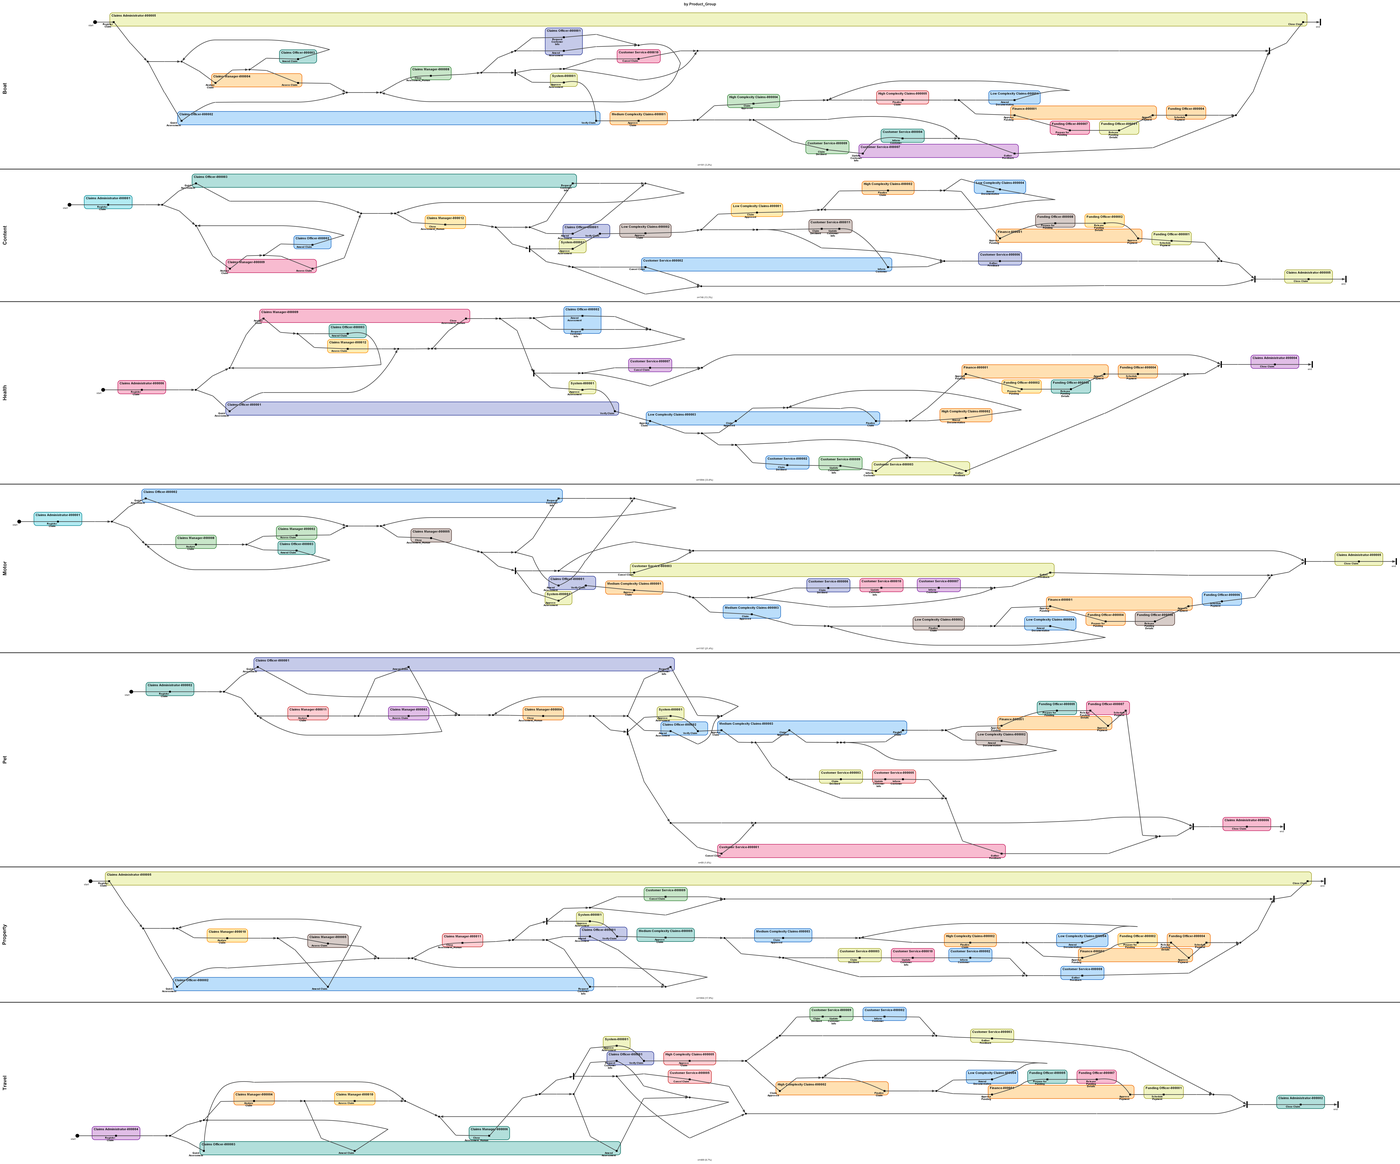

In [6]:
grid_png = pm4py_ucm.save_vis_ucm_family(
    family, str(OUT / "family_by_product.png"),
)
show(grid_png, max_width=1400)

## 5. Export the family

Two file-level exports:

* `write_ucm_family` — one `.jucm` per combination plus a
  `family_summary.csv`, as a zip archive or a directory;
* `assemble_ucm_family(mode="combined")` — every cell model as an
  independent root map in **one** URN spec, built in one container:
  one ID counter (byte-deterministic export) and **shared
  responsibility/component definitions** — the same activity appearing
  in several cells is one definition referenced from many maps.

In [7]:
zip_path = pm4py_ucm.write_ucm_family(family, str(OUT / "family.zip"))
with zipfile.ZipFile(zip_path) as zf:
    print("\n".join(zf.namelist()))

Product_Group=Boat.jucm
Product_Group=Content.jucm
Product_Group=Health.jucm
Product_Group=Motor.jucm
Product_Group=Pet.jucm
Product_Group=Property.jucm
Product_Group=Travel.jucm
family_summary.csv


In [8]:
combined = pm4py_ucm.assemble_ucm_family(family, mode="combined")
pm4py_ucm.write_ucm(combined, str(OUT / "family_combined.jucm"))

# Shared definitions: "Register Claim" exists ONCE, referenced from
# every cell's map.
reg = next(r for r in combined.responsibilities
           if r.name == "Register Claim")
refs = combined.find_resp_refs(reg)
print(f"maps: {len(combined.maps)}, "
      f"responsibility definitions: {len(combined.responsibilities)}")
print(f"'Register Claim' is 1 definition with {len(refs)} references, "
      f"on maps: {sorted({r.diagram.name for r in refs})}")

maps: 7, responsibility definitions: 25
'Register Claim' is 1 definition with 7 references, on maps: ['Boat', 'Content', 'Health', 'Motor', 'Pet', 'Property', 'Travel']


## 6. The umbrella: one overarching model with dynamic stubs

`assemble_ucm_family(mode="umbrella")` **anti-unifies** the per-cell
process trees into a shared skeleton: identical subtrees are shared
verbatim on the root map; sequences share their longest common
prefix/suffix; loops merge on (do, redo); whatever differs becomes a
**variation point** — a *dynamic stub* whose plug-ins are the variant
sub-maps, guarded by preconditions over the partition attributes.

Three behaviours worth noticing in the output below:

* **resource variation counts as variation** — the same activity
  performed by a different actor in different cells becomes a
  variation point, each variant drawn inside its cells' actor;
* **dedup with domain-factored conditions** — behaviourally identical
  variants share one plug-in; when a value's variants cover *every*
  value of the other attribute, that attribute drops out of the
  condition entirely;
* **plug-in names carry the values they cover**
  (`Register Claim [AUS | NZL]`), so jUCMNav's tree reads meaningfully.

In [9]:
from pm4py_ucm import UCM

umbrella = pm4py_ucm.assemble_ucm_family(family, mode="umbrella")
pm4py_ucm.write_ucm(umbrella, str(OUT / "family_umbrella.jucm"))

root = umbrella.maps[0]
# (path scenarios add synthetic decrement responsibilities for the
# loop counters — exclude them from the "shared activities" view)
shared = [n.resp_def.name for n in root.nodes
          if isinstance(n, UCM.RespRef)
          and not n.resp_def.name.startswith("decrement_")]
stubs = [n for n in root.nodes if isinstance(n, UCM.Stub) and n.dynamic]
print(f"root map: shared activities {shared}, "
      f"{len(stubs)} variation point(s)\n")
for stub in stubs:
    print(f"[stub '{stub.name}'] {len(stub.bindings)} variant(s):")
    for b in stub.bindings:
        actor = next((n.cont_ref.cont_def.name for n in b.plugin.nodes
                      if isinstance(n, UCM.RespRef)
                      and n.cont_ref is not None), "-")
        print(f"   '{b.plugin.name}'  actor={actor}")
        print(f"      when {b.precondition.expression}")
    print()

root map: shared activities [], 6 variation point(s)

[stub 'Register Claim'] 5 variant(s):
   'Register Claim [Boat | Property]'  actor=Claims Administrator-000005
      when Product_Group == Boat || Product_Group == Property
   'Register Claim [Content | Motor]'  actor=Claims Administrator-000001
      when Product_Group == Content || Product_Group == Motor
   'Register Claim [Health]'  actor=Claims Administrator-000006
      when Product_Group == Health
   'Register Claim [Pet]'  actor=Claims Administrator-000002
      when Product_Group == Pet
   'Register Claim [Travel]'  actor=Claims Administrator-000004
      when Product_Group == Travel

[stub 'Quick Assessment'] 7 variant(s):
   'Quick Assessment to Assess Claim [Boat]'  actor=Claims Officer-000002
      when Product_Group == Boat
   'Quick Assessment to Assess Claim [Content]'  actor=Claims Officer-000003
      when Product_Group == Content
   'Quick Assessment to Assess Claim [Health]'  actor=Claims Officer-000001
      when

### Strategies are executable *path* scenarios

By default each combination gets one scenario per **behavioural
variant** of its sub-log (concurrency-aware replay, top 5 by
frequency): the attribute variables select the plug-in at every
dynamic stub, a `family_variant` value selects the branch at every
outside-loop OR-fork, and per-loop counters bound the iterations —
so in jUCMNav, different strategies genuinely traverse different
paths. Inside-loop two-way XORs get combined
`family_variant && counter`-range conditions.

In [10]:
group = umbrella.scenario_groups[0]
print(f"{len(group.scenarios)} scenarios; first six:\n")
for s in group.scenarios[:6]:
    inits = {i.variable.name: i.value for i in s.initializations}
    print(f"  {s.name:<16} {inits}")

conditioned = sum(
    1 for m in umbrella.maps for n in m.nodes
    if isinstance(n, UCM.OrFork)
    for arc in n.succ_connections
    if arc.condition is not None and arc.condition.expression
    and arc.condition.expression != "true"
)
total = sum(
    len(n.succ_connections) for m in umbrella.maps for n in m.nodes
    if isinstance(n, UCM.OrFork)
)
print(f"\nOR-fork branch arcs with real conditions: {conditioned}/{total}")

35 scenarios; first six:

  Boat v1          {'Product_Group': 'Boat', 'family_variant': 'Boat_v1', 'loop_counter_3': '1', 'Loop_FinalizeClaim': '1'}
  Boat v2          {'Product_Group': 'Boat', 'family_variant': 'Boat_v2', 'Loop_AnalyzeClaim': '1', 'loop_counter_3': '1', 'Loop_FinalizeClaim': '1'}
  Boat v3          {'Product_Group': 'Boat', 'family_variant': 'Boat_v3', 'loop_counter_3': '1'}
  Boat v4          {'Product_Group': 'Boat', 'family_variant': 'Boat_v4', 'loop_counter_3': '2', 'Loop_FinalizeClaim': '1'}
  Boat v5          {'Product_Group': 'Boat', 'family_variant': 'Boat_v5', 'Loop_AnalyzeClaim': '1', 'loop_counter_3': '1'}
  Content v1       {'Product_Group': 'Content', 'family_variant': 'Content_v1', 'Loop_AnalyzeClaim_2': '1', 'loop_counter_3': '1', 'Loop_FinalizeClaim_2': '1'}

OR-fork branch arcs with real conditions: 128/128


For contrast, `skeleton=False` produces the *trivial* umbrella — a
single `start → dynamic stub → end` root map whose plug-ins are the
whole cell models. It selects between models but shows nothing about
*where* they differ; the skeleton form is almost always what you want.

In [11]:
trivial = pm4py_ucm.assemble_ucm_family(
    family, mode="umbrella", skeleton=False, path_scenarios=False,
)
t_root = trivial.maps[0]
t_stub = next(n for n in t_root.nodes if isinstance(n, UCM.Stub))
print(f"trivial umbrella: {len([n for n in t_root.nodes if isinstance(n, UCM.RespRef)])} "
      f"shared activities, 1 stub with {len(t_stub.bindings)} whole-model plug-ins")

trivial umbrella: 0 shared activities, 1 stub with 7 whole-model plug-ins


## 7. Two attributes, binning, and value filters

With two attributes the family is a matrix: rows = first attribute,
columns = second. `Claim_Value` is numeric, so it partitions into
quantile ranges (`bins=3`); `include_values` restricts an attribute to
the listed values (cases carrying other values are dropped) — the same
filter the web app exposes as per-attribute multiselects.

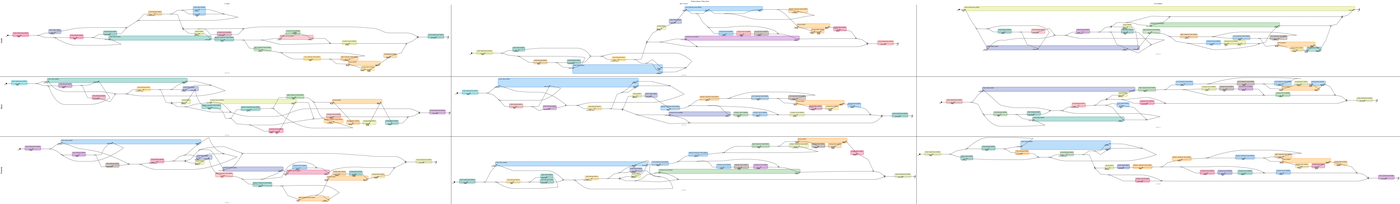

In [12]:
family2 = pm4py_ucm.discover_ucm_family(
    df, ["Product_Group", "Claim_Value"],
    bins=3, min_cases=50, noise_threshold=0.2,
    include_values={"Product_Group": ["Health", "Motor", "Property"]},
)
grid2 = pm4py_ucm.save_vis_ucm_family(
    family2, str(OUT / "family_matrix.png"),
)
show(grid2, max_width=1400)

## 8. Performance overlays: frequencies and times

`annotate_performance` computes statistics from the log and attaches
them to the model. You pick **up to two metrics per layer** for the
visual overlay; *every* available metric is additionally exported as
its own jUCMNav metadata line.

| layer | metrics |
|---|---|
| activities | `frequency`, `case_coverage`, `mean/median/total_time` (service time — needs an interval log) |
| edges | `frequency`, `percentage` (OR-fork branch share), `mean/median/total_time` (waiting time) |

Edge statistics are attributed via activity-to-activity **segments**
that walk through routing bends, joins, forks, and static stubs — so
decomposed models are covered, and an OR-fork sitting right after a
join still gets branch statistics (the aggregate over its upstream
activities).

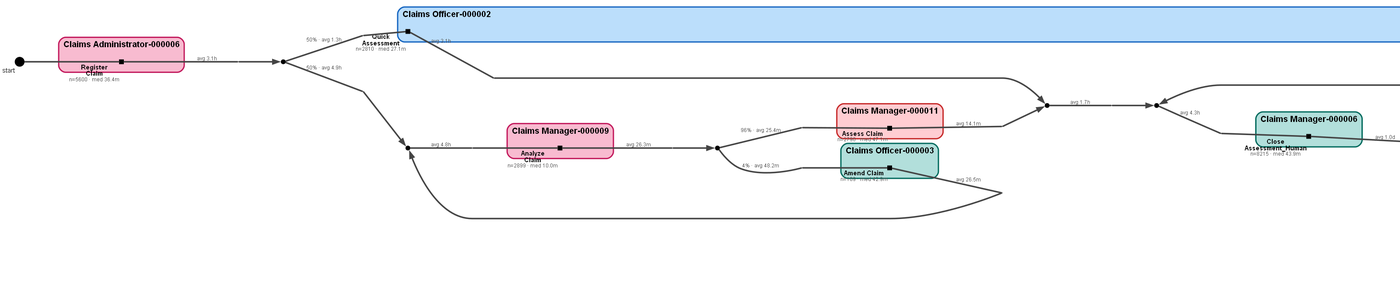

In [13]:
single = pm4py_ucm.discover_ucm_inductive(
    df, parameters={
        "process_tree": pm4py.discover_process_tree_inductive(
            df, noise_threshold=0.2),
    },
)
pm4py_ucm.annotate_performance(
    single, df,
    node_metrics=["frequency", "median_time"],
    edge_metrics=["percentage", "mean_time"],
)
png = pm4py_ucm.save_vis_ucm(single, str(OUT / "annotated.png"))
# Zoom into the first choice so the overlay text is readable inline:
# activity captions ("n=5600 · med 36.4m") and branch captions
# ("50% · avg 1.3h").
show(png, max_width=1400, crop=(0, 0, 3200, 700))

Note `Analyze Claim`: its execution count exceeds its case coverage —
executions above cases is loop rework, visible at a glance.

In the exported `.jucm`, every metric is one metadata line — jUCMNav
lists them in the properties view of the activity (or, for edge
metrics, of the arc's source node, branch-indexed: `perf_branch0_…`
is the node's first outgoing arc).

In [14]:
import re

jucm = pm4py_ucm.write_ucm(single, str(OUT / "annotated.jucm"))
text = Path(jucm).read_text(encoding="utf-8")
block = re.search(
    r'<nodes [^>]*name="Quick[^"]*"[^>]*>(.*?)</nodes>', text, re.S,
).group(1)
print("\n".join(l.strip() for l in block.splitlines()
                if "metadata" in l))

<metadata name="perf_frequency" value="2810"/>
<metadata name="perf_case_coverage" value="2810"/>
<metadata name="perf_mean_time" value="2.5h"/>
<metadata name="perf_median_time" value="27.1m"/>
<metadata name="perf_total_time" value="297.4d"/>
<metadata name="_perf" value="n=2810 · med 27.1m"/>
<metadata name="perf_branch0_frequency" value="2810"/>
<metadata name="perf_branch0_mean_time" value="3.1h"/>
<metadata name="perf_branch0_median_time" value="11.7m"/>
<metadata name="perf_branch0_total_time" value="360.2d"/>
<metadata name="_perf_branch0" value="avg 3.1h"/>


The same statistics are available programmatically — useful for
analysis beyond the diagram, e.g. the busiest activities and the
slowest hand-offs:

In [15]:
from pm4py_ucm.algo.performance import compute_performance_stats

stats = compute_performance_stats(df)

busiest = pd.DataFrame([
    {"activity": a, **v} for a, v in stats.activity.items()
]).sort_values("frequency", ascending=False).head(5)
display(busiest.reset_index(drop=True))

slowest = pd.DataFrame([
    {"from": a, "to": b, "traversals": v["frequency"],
     "mean wait (h)": round(v["mean_time"] / 3600, 1)}
    for (a, b), v in stats.pairs.items() if v["frequency"] >= 100
]).sort_values("mean wait (h)", ascending=False).head(5)
display(slowest.reset_index(drop=True))

,activity,frequency,case_coverage,mean_time,median_time,min_time,max_time,total_time,sojourn_mean_time,sojourn_median_time,sojourn_min_time,sojourn_max_time,sojourn_total_time
0,Close Assessment_Human,8215,5600,14035.337650,2632.7110,0.742,256215.220,1.153003e+08,29560.205169,4529.588,0.742,272505.704,2.428371e+08
1,Register Claim,5600,5600,12755.640429,2182.2915,0.084,252819.869,7.143159e+07,NaN,NaN,NaN,NaN,NaN
2,Close Claim,5600,5600,4950.367650,817.1665,0.616,236249.347,2.772206e+07,7127.350751,1336.235,0.616,238478.313,3.991316e+07
3,Approve Assessment,4990,4990,0.000000,0.0000,0.000,0.000,0.000000e+00,0.000000,0.000,0.000,0.000,0.000000e+00
4,Verify Claim,4990,4990,85.407620,27.3915,0.013,57688.822,4.261840e+05,1253.140729,103.263,0.013,232729.975,6.253172e+06


,from,to,traversals,mean wait (h)
0,Close Assessment_Human,Cancel Claim,610,324.3
1,Approve Claim,Claim Declined,1386,304.0
2,Approve Funding,Prepare for Funding,3604,291.0
3,Request Customer Info,Close Assessment_Human,771,30.3
4,Amend Documentation,Finalize Claim,263,29.1


Overlays compose with families: per-cell models are annotated from
each cell's own sub-log, and the assemblies take the metric selections
too — the umbrella's shared skeleton is annotated from the **whole**
family log, each variant plug-in from its **covering cells'** sub-log.

In [16]:
umbrella_perf = pm4py_ucm.assemble_ucm_family(
    family, mode="umbrella",
    node_metrics=["frequency", "median_time"],
    edge_metrics=["percentage", "mean_time"],
)
pm4py_ucm.write_ucm(umbrella_perf,
                    str(OUT / "family_umbrella_annotated.jucm"))

def perf_of(node):
    return next((md.value for md in node.metadata
                 if md.name == "_perf"), None)

root = umbrella_perf.maps[0]
annotated_root = [n for n in root.nodes
                  if isinstance(n, UCM.RespRef) and perf_of(n)]
if annotated_root:
    n = annotated_root[0]
    print(f"skeleton  '{n.resp_def.name}': {perf_of(n)}"
          "   <- whole family log")
else:
    print("(this family's skeleton keeps no shared activities — every "
          "activity's\n performer differs by product group, so all of "
          "them live in variant\n plug-ins; skeleton-level statistics "
          "then appear on the stub arcs)")
stub = next(n for n in root.nodes
            if isinstance(n, UCM.Stub) and n.dynamic)
for b in stub.bindings[:3]:
    n = next((x for x in b.plugin.nodes
              if isinstance(x, UCM.RespRef) and perf_of(x)), None)
    if n is not None:
        print(f"plug-in   '{b.plugin.name}' / '{n.resp_def.name}': "
              f"{perf_of(n)}   <- covering cells only")

(this family's skeleton keeps no shared activities — every activity's
 performer differs by product group, so all of them live in variant
 plug-ins; skeleton-level statistics then appear on the stub arcs)
plug-in   'Register Claim [Boat | Property]' / 'Register Claim': n=1185 · med 34.7m   <- covering cells only
plug-in   'Register Claim [Content | Motor]' / 'Register Claim': n=1943 · med 36.9m   <- covering cells only
plug-in   'Register Claim [Health]' / 'Register Claim': n=1894 · med 38.1m   <- covering cells only


## 9. Family statistics and the interactive report

Rendering the models side by side shows *how* the family's
processes differ; `compute_family_stats` quantifies it. One call
— **while `family.log_df` is still available** — yields four
levels of statistics designed for cross-cell comparison:

* **process** — cases, events, events/case, case-duration
  min/mean/median/max and **total**, behavioural variant counts,
  replay fitness;
* **activity** — frequency, case coverage, **sojourn** time
  (since the case's previous event — available even for
  single-timestamp logs) and, on interval logs like this one,
  service-time min/mean/median/max/total;
* **edge** — directly-follows pairs with traversal frequency and
  waiting times, busiest handovers first;
* **choice** — OR-fork branch counts **aligned across the cells**
  through the family's shared skeleton, so the same decision
  point is one comparable row for every combination.

Metrics the log cannot support are omitted, never fabricated.

In [17]:
fam_stats = pm4py_ucm.compute_family_stats(family)
fam_stats.process_frame()

,cases,coverage_pct,events,activities,events_per_case_mean,events_per_case_median,events_per_case_min,events_per_case_max,duration_mean_s,duration_median_s,duration_min_s,duration_max_s,duration_total_s,variants,sequence_variants,fitness_pct
cell,,,,,,,,,,,,,,,,
Boat,181,3.2,2525,25,13.950276,14.0,6.0,22.0,1.287951e+06,1.313933e+06,97245.382,2603275.249,2.331192e+08,13,39,89.5
Content,746,13.3,10325,25,13.840483,14.0,6.0,25.0,1.347522e+06,1.395793e+06,93308.112,2758534.109,1.005252e+09,15,64,88.7
Health,1894,33.8,26370,25,13.922914,14.0,6.0,27.0,1.304984e+06,1.376174e+06,86884.767,2773866.257,2.471639e+09,17,105,88.4
Motor,1197,21.4,16719,25,13.967419,14.0,6.0,25.0,1.284236e+06,1.305546e+06,14567.998,2675709.983,1.537231e+09,17,86,89.8
Pet,89,1.6,1308,25,14.696629,15.0,7.0,20.0,1.441680e+06,1.623933e+06,169323.894,2420784.679,1.283095e+08,11,25,93.3
Property,1004,17.9,14081,25,14.024900,14.0,6.0,27.0,1.272387e+06,1.304855e+06,80704.437,2764273.094,1.277476e+09,16,84,89.8
Travel,489,8.7,6798,25,13.901840,14.0,6.0,25.0,1.305046e+06,1.319626e+06,10377.471,2669756.042,6.381676e+08,15,59,88.3


The pandas views make ranking questions one-liners — which
product group spends the most **total** service time per
activity, and which handovers wait longest:

In [18]:
display(fam_stats.activity_frame("total_time").head(8))
display(fam_stats.edge_frame("mean_time").head(8))

,Boat,Content,Health,Motor,Pet,Property,Travel
Amend Assessment,79181.579,4.445054e+05,1.056164e+06,9.045086e+05,16038.344,7.194023e+05,4.196657e+05
Amend Claim,15196.028,8.734900e+04,5.148689e+05,1.048749e+05,8766.408,6.397648e+05,3.281639e+05
Amend Documentation,722563.599,1.081251e+06,2.093283e+06,2.312852e+06,341394.112,2.339912e+06,3.817816e+05
Analyze Claim,296740.896,2.560311e+06,3.040666e+06,2.883936e+06,327936.888,2.130012e+06,1.030793e+06
Approve Assessment,0.000,0.000000e+00,0.000000e+00,0.000000e+00,0.000,0.000000e+00,0.000000e+00
Approve Claim,6689381.587,2.435099e+07,6.294051e+07,3.969384e+07,3488029.270,3.240487e+07,1.468258e+07
Approve Funding,125367.865,7.549965e+05,2.064136e+06,2.002680e+06,152361.905,1.582890e+06,2.162616e+05
Approve Payment,626632.196,1.576988e+06,5.750694e+06,4.210380e+06,309407.750,1.454156e+06,7.846367e+05


,Boat,Content,Health,Motor,Pet,Property,Travel
Approve Assessment → Verify Claim,278.597864,1.470143e+03,1.089438e+03,1.139912e+03,3.124226e+02,1.104082e+03,1.707600e+03
Close Assessment_Human → Approve Assessment,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
Verify Claim → Approve Claim,22467.197790,2.239484e+04,1.894169e+04,1.825221e+04,1.937481e+04,1.903610e+04,2.027130e+04
Approve Claim → Claim Approved,339.432474,2.432654e+03,1.160039e+03,3.034692e+02,1.205457e+03,9.975618e+02,8.137279e+02
Approve Funding → Prepare for Funding,973517.859833,1.064073e+06,1.062961e+06,1.024818e+06,1.224585e+06,1.029182e+06,1.044365e+06
Approve Payment → Schedule Payment,2493.430202,2.719173e+03,2.004543e+03,2.633259e+03,4.143026e+02,1.217647e+03,2.481877e+03
Claim Approved → Finalize Claim,194.430211,1.213947e+03,4.997605e+02,5.891887e+02,1.002492e+03,6.678940e+02,4.288229e+02
Finalize Claim → Approve Funding,91.968482,2.026131e+02,3.676503e+02,1.750255e+02,9.667739e+02,2.815786e+02,6.983210e+01


Choice statistics are aligned by anti-unifying the per-cell
process trees into the family skeleton (the same merge that
builds the umbrella, control-flow only) and replaying each
cell's sub-log on its configured tree — forks are named by
their context, flagged when they sit inside a loop, and cells
that never reach a fork show `NaN` ("not reached"), distinct
from zero:

In [19]:
for ch in fam_stats.choices:
    kind = "shared" if ch.shared else "variation-point"
    print(f"{ch.choice_id}: {ch.full_name}  [{kind}"
          + (", inside loop]" if ch.inside_loop else "]"))
fam_stats.choice_share_frame(fam_stats.choices[0]).round(1)

choice_1: after Register Claim: Quick Assessment vs Analyze Claim  [shared]
choice_2: after Close Assessment_Human: Amend Assessment vs Request Customer Info  [shared, inside loop]
choice_3: after Request Customer Info: (skip) vs Cancel Claim  [shared]
choice_4: after Approve Claim: Claim Declined vs Claim Approved  [shared]
choice_5: after Approve Claim: (skip) vs Claim Declined  [shared]


,Quick Assessment,Analyze Claim
Boat,53.1,46.9
Content,48.6,51.4
Health,50.7,49.3
Motor,50.5,49.5
Pet,48.2,51.8
Property,51.0,49.0
Travel,48.1,51.9


### The self-contained interactive HTML report

`write_family_report` packs everything above — plus the cell
model images — into **one HTML file with zero external
dependencies** (statistics embedded as JSON, images as base64
PNGs, vanilla JavaScript): it opens offline in any browser and
is archivable as supplementary material. Five interactive
views: a sortable heat-mapped **Overview**, a pairwise
**Compare** (any two members side by side with their models,
delta cards, activity/edge Δ tables, aligned choice bars),
**Activities** and **Edges** matrices, **Choices** as 100%
stacked bars, and a model **gallery**. Open the file in several
browser tabs to compare several pairs at once.

The same report is a one-click download in the V3 web app
(Family and Compare tabs).

In [20]:
report_path = pm4py_ucm.write_family_report(
    family, str(OUT / "family_report.html"), stats=fam_stats,
    title="ClaimsPaymentLog — family by product group",
)
size_mb = Path(report_path).stat().st_size / 1e6
print(f"{report_path}  ({size_mb:.1f} MB, self-contained — "
      "open it in a browser)")

C:\Users\jucmn\Claude\pm4py-ucm\demo\output\families\family_report.html  (1.8 MB, self-contained — open it in a browser)


## 10. Wrap-up

The complete family API surface:

```python
family   = pm4py_ucm.discover_ucm_family(log, attrs, decomposition=…,
                                         min_cases=…, bins=…,
                                         include_values=…)
pm4py_ucm.write_ucm_family(family, "family.zip")       # per-cell .jucm
pm4py_ucm.save_vis_ucm_family(family, "grid.png")      # stack / matrix
combined = pm4py_ucm.assemble_ucm_family(family, mode="combined")
umbrella = pm4py_ucm.assemble_ucm_family(family, mode="umbrella",
                                         node_metrics=…, edge_metrics=…)
pm4py_ucm.annotate_performance(ucm, log, node_metrics=…, edge_metrics=…)
fam_stats = pm4py_ucm.compute_family_stats(family)   # 4-level statistics
pm4py_ucm.write_family_report(family, "report.html", stats=fam_stats)
```

Where to go next:

* [`docs/model_families.md`](../docs/model_families.md) — full
  reference: partitioning policy, skeleton merge rules, resource
  variation, dedup and factored conditions, path scenarios, overlay
  metrics and segment attribution, metadata schema, known limitations.
* The **Family** and **Compare** tabs of `web/streamlit_app_v3.py`
  — all of the above interactively, with a pre-mining coverage
  heatmap, per-attribute value filters, and the statistics report
  as a download.
* Every `.jucm` written to `output/families/` opens directly in
  jUCMNav — the umbrella with its dynamic stubs, preconditions, and
  executable strategies included.